## Exploratory Data Analysis on Large Dataset
## Breaking Data into Groups
The first thing that stood out on this EDA is that there are so many columns, the most I've ever seen on a dataset. One of the first things I do with a datset is run an .info(), but the code didn't work as intended. It still provides some information, but doesn't itemize the 227 columns. I researched how to handle this challenge, and discovered that categorizing the columns so that you can run EDA in chunks is a popular method. Using the codebook from Women’s Bureau National Database of Childcare Prices Technical Report, I broke the columns into groups. 

### Code Attribution 
<ul>
  <li> Title: Matplotlib Tutorials
  <li> Author: Matplotlib
  <li> Date: 14|December 2025
  <li> Modified By: Charlotte Alley
  <li> Description: Code offers basics of how to create visualizaitons in Matplotlib 

<ul>
  <li> Title: The Data Wrangling Workshop
  <li> Author: Brian Lipp, Shubhadeep Roychowdhury, Dr. Tirthajyoti Sarkar
  <li> Date: 14 December 2025
  <li> Modified By: Charlotte Alley
  <li> Description: Data Sources & Data Wrangling

In [3]:
import pandas as pd
import regex as re
import matplotlib.pyplot as plt

In [4]:
childcare_df = pd.read_excel('nationaldatabaseofchildcareprices.xlsx')

In [95]:
# Creates list of column names 
cols = childcare_df.columns

# Uses regular expression to group columns by category for segmented analysis
id_cols = cols[cols.str.contains('State|County|Study', regex=True, case=True)]
labor_cols = cols[cols.str.contains('UNR|LFPR', regex=True, case=True)]
income_cols = cols[cols.str.contains('MHI|PR_F|PR_P|ME', regex=True, 
                                     case=True) & 
                   ~cols.str.contains('EMP', regex=True, na=False)]
demo_cols = cols[cols.str.contains('Pop|Race|Hispanic', regex=True, case=True)]
household_cols = cols[cols.str.contains('House|H_', regex=True, case=True)]
job_type_cols = cols[cols.str.contains('EMP_', regex=True, case=True)]
price_cols = cols[cols.str.contains('MC|MFC', regex=True, case=True)]
percentile_cols = cols[cols.str.contains('_75', regex=True, case=False)]

## Column Completeness & Datatypes
Only three columns are of the object datatype. Something that stands out to me is the missing values for the price and percentile columns. After looking more at the technical guide, they were upfront about the imputation methods that were used and their limitations. It was also expressed that there were many data points for which imputation wouldn't be appropriate, due to its bias effect potential. These missing values will need to be taken into account for the analysis.

In [96]:
childcare_df[price_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34567 entries, 0 to 34566
Data columns (total 56 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MCBto5              23593 non-null  float64
 1   MC6to11             23593 non-null  float64
 2   MC12to17            23593 non-null  float64
 3   MC18to23            23593 non-null  float64
 4   MC24to29            23593 non-null  float64
 5   MC30to35            23593 non-null  float64
 6   MC36to41            23593 non-null  float64
 7   MC42to47            23593 non-null  float64
 8   MC48to53            23593 non-null  float64
 9   MC54toSA            23593 non-null  float64
 10  MCSA                23593 non-null  float64
 11  MFCCBto5            23383 non-null  float64
 12  MFCC6to11           23383 non-null  float64
 13  MFCC12to17          23383 non-null  float64
 14  MFCC18to23          23383 non-null  float64
 15  MFCC24to29          23383 non-null  float64
 16  MFCC

In [107]:
# Conducts sanity check to ensure all columns included in grouping 
all_grouped = (id_cols.tolist() + labor_cols.tolist() + income_cols.tolist() + 
               demo_cols.tolist() + household_cols.tolist() + 
               job_type_cols.tolist() + price_cols.tolist() + percentile_cols.tolist())
print(f"Total cols: {len(cols)}, Grouped: {len(all_grouped)}")

Total cols: 227, Grouped: 227


## Descriptive Statistics
Any column that begins with a lowercase i is a boolean imputation column (0's for not imputed, 1 for imputed, with varying lengths dependent on column specifications). For now, I'll be focusing my attention on the non-'i' columns. The first group has unemployment and labor force participation rates based on age groups. For the unemployment rates, you can see that the means are slightly higher than the median values (50th percentile), indicating some skew and outliers. The ranges are interesting, with the highest unemployment rate seen in Males from 20 to 64, but the lowest rate of 0 seen in each age category. With the income group, a pattern emerges with women earning less. The range between poverty rates within counties is interesting, from 0-55% for individuals and 0-52% for families. The minimums and maximums for the demographics group showed that there are communities that identify as entirely white, but no counties that identify as 100% of any other race. With the household group, the medians of one or both parents working increase from the 6 and under to the 6-17 age group, suggesting that parents with younger children are less likely to be in the work force. I want to look at whether there are more single mothers with children 6 and under compared to when the data was first collected, as well as how the share of parents both working has evolved over time. The job types group identifies some patterns, with males seeing higher median percentages in management, natural resources, construction and maintenence jobs and females seeing higher participation in service and sales occupations. Looking at the price group, I know that the costs have gone up since this data came out in 2018, based off the amount that I've been paying for my daughter born in 2022. It's also obvious that family care is cheaper than center-based care. 

In [99]:
childcare_df[labor_cols].describe()

,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,MUNR_20to64,FLFPR_20to64,FLFPR_20to64_Under6,FLFPR_20to64_6to17,FLFPR_20to64_Under6_6to17,...,iFUNR_16,iMUNR_16,iUNR_20to64,iFUNR_20to64,iMUNR_20to64,iFLFPR_20to64,iFLFPR_20to64_Under6,iFLFPR_20to64_6to17,iFLFPR_20to64_Under6_6to17,iMLFPR_20to64
count,34567.000000,34567.00000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,7.465902,7.02902,7.860291,6.900073,6.482007,7.275457,70.086125,68.821409,78.824106,66.940759,...,0.038881,0.038881,0.038881,0.038881,0.038881,0.038881,0.040530,0.636590,0.637082,0.038881
std,3.538619,3.56342,4.037657,3.446199,3.477956,3.990758,7.696499,11.758088,8.529813,13.285061,...,0.193314,0.193314,0.193314,0.193314,0.193314,0.193314,0.197201,0.480988,0.480849,0.193314
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,33.600000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.100000,4.64000,5.200000,4.600000,4.200000,4.700000,65.100000,62.600000,74.400000,59.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.050000,6.59000,7.390000,6.500000,6.000000,6.800000,70.600000,69.600000,79.450000,67.660000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,9.350000,8.88000,9.920000,8.700000,8.250000,9.200000,75.500000,76.100000,84.225000,75.200000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,36.110000,38.24000,39.740000,33.900000,44.500000,45.500000,100.000000,100.000000,100.000000,100.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [100]:
childcare_df[income_cols].describe()

,PR_F,PR_P,MHI,ME,FME,MME,MHI_2018,ME_2018,FME_2018,MME_2018,iPR_F,iPR_P,iMHI,iME,iFME,iMME,iMHI_2018,iME_2018,iFME_2018,iMME_2018
count,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.00000
mean,11.739125,16.038131,46432.001931,27075.054081,21625.047495,33134.232570,50446.777363,29404.295539,23475.169710,35997.433918,0.038245,0.038158,0.038245,0.038447,0.038476,0.038505,0.909133,0.909191,0.909104,0.90922
std,5.681003,6.511816,12457.050093,5483.484930,4716.600817,7240.296013,13279.833788,5715.192737,4903.836942,7643.855532,0.191789,0.191580,0.191789,0.192276,0.192345,0.192415,0.287424,0.287342,0.287465,0.28730
min,0.000000,0.000000,18528.560000,4417.000000,4290.000000,3784.000000,19841.920000,4947.040000,5019.300000,4238.080000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,7.700000,11.400000,38250.500000,23636.000000,18721.000000,28729.000000,41839.215000,25955.055000,20613.100000,31447.505000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000
50%,10.900000,15.200000,44438.000000,26366.000000,21089.000000,32059.000000,48505.600000,28653.920000,22854.700000,35103.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000
75%,14.600000,19.500000,52078.390000,30022.500000,23919.000000,36543.500000,56201.450000,32005.820000,25634.665000,39503.335000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.00000
max,52.100000,55.100000,136268.000000,70565.000000,62919.000000,93000.000000,136268.000000,70565.000000,68600.000000,98580.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [101]:
childcare_df[demo_cols].describe()

,TotalPop,OneRace,OneRace_W,OneRace_B,OneRace_I,OneRace_A,OneRace_H,OneRace_Other,TwoRaces,Hispanic,iTotalPop,iOneRace,iOneRace_W,iOneRace_B,iOneRace_I,iOneRace_A,iOneRace_H,iOneRace_Other,iTwoRaces,iHispanic
count,3.456700e+04,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,9.914222e+04,97.922863,83.636247,8.971213,1.895634,1.216209,0.082101,2.117914,2.077146,8.401054,0.038187,0.044956,0.044956,0.044956,0.044956,0.044956,0.044956,0.044956,0.044956,0.046808
std,3.177786e+05,1.952523,16.683515,14.510260,7.517786,2.633768,0.593602,3.779858,1.952520,13.284933,0.191650,0.207211,0.207211,0.207211,0.207211,0.207211,0.207211,0.207211,0.207211,0.211230
min,4.100000e+01,59.500000,3.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.101450e+04,97.500000,77.000000,0.600000,0.200000,0.200000,0.000000,0.300000,1.100000,1.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.571100e+04,98.400000,90.200000,2.100000,0.300000,0.500000,0.000000,0.800000,1.600000,3.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6.670350e+04,98.900000,95.600000,10.200000,0.800000,1.200000,0.100000,2.200000,2.500000,8.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.010572e+07,100.000000,100.000000,87.400000,95.700000,52.200000,35.300000,58.800000,40.500000,99.200000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [102]:
childcare_df[household_cols].describe()

,Households,H_Under6_BothWork,H_Under6_FWork,H_Under6_MWork,H_Under6_SingleM,H_6to17_BothWork,H_6to17_Fwork,H_6to17_Mwork,H_6to17_SingleM,iHouseholds,iH_Under6_BothWork,iH_Under6_FWork,iH_Under6_MWork,iH_Under6_SingleM,iH_6to17_BothWork,iH_6to17_Fwork,iH_6to17_Mwork,iH_6to17_SingleM
count,3.456700e+04,34567.000000,34567.000000,34567.000000,34565.000000,34567.000000,34567.000000,34567.000000,34565.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000
mean,3.686299e+04,2791.610004,1821.628808,141.109064,1992.249964,6480.568548,2874.374374,390.113056,3924.511558,0.038187,0.038447,0.038447,0.038447,0.040732,0.038447,0.038447,0.038447,0.040732
std,1.116470e+05,8709.085062,6740.389344,472.557239,7009.934446,19294.344762,10901.264277,1187.096922,13966.245194,0.191650,0.192276,0.192276,0.192276,0.197673,0.192276,0.192276,0.192276,0.197673
min,2.200000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.236000e+03,260.000000,146.000000,5.000000,176.000000,685.000000,247.000000,39.000000,351.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.814000e+03,647.000000,387.000000,31.000000,489.000000,1662.000000,620.000000,116.000000,907.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.549350e+04,1786.000000,1099.000000,103.000000,1298.000000,4469.500000,1767.000000,306.000000,2421.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.306109e+06,264439.000000,246269.000000,15396.000000,220530.000000,590730.000000,391225.000000,40499.000000,436538.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
childcare_df[job_type_cols].describe()

,EMP_M,MEMP_M,FEMP_M,EMP_Service,MEMP_Service,FEMP_Service,EMP_Sales,MEMP_Sales,FEMP_Sales,EMP_N,...,iFEMP_Service,iEMP_Sales,iMEMP_Sales,iFEMP_Sales,iEMP_N,iMEMP_N,iFEMP_N,iEMP_P,iMEMP_P,iFEMP_P
count,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,34567.000000,...,34567.0,34567.0,34567.0,34567.0,34567.0,34567.0,34567.0,34567.0,34567.0,34567.0
mean,30.720191,26.495400,35.509491,17.909716,13.122111,23.424303,22.244044,13.660359,32.062036,13.076182,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,6.503783,8.013214,6.073988,3.602868,4.476415,4.696024,3.352621,3.761803,4.480591,4.257660,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,26.340000,20.945000,31.560000,15.590000,10.270000,20.410000,20.150000,11.210000,29.390000,10.200000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,29.690000,25.190000,34.940000,17.580000,12.840000,23.090000,22.410000,13.680000,32.170000,12.560000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,34.100000,30.720000,38.870000,19.780000,15.450000,26.010000,24.540000,16.240000,34.800000,15.340000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,74.030000,76.890000,100.000000,46.420000,56.330000,62.780000,50.770000,49.060000,100.000000,60.000000,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [104]:
childcare_df[price_cols].describe()

,MCBto5,MC6to11,MC12to17,MC18to23,MC24to29,MC30to35,MC36to41,MC42to47,MC48to53,MC54toSA,...,MCToddler,MCToddler_flag,MCPreschool,MCPreschool_flag,MFCCInfant,MFCCInfant_flag,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag
count,23593.000000,23593.000000,23593.000000,23593.000000,23593.000000,23593.000000,23593.000000,23593.000000,23593.000000,23593.000000,...,23593.000000,23593.000000,23593.000000,23593.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000,23383.000000
mean,145.930609,145.929977,142.769363,139.820997,130.482768,128.298475,122.197682,122.197192,120.114848,120.115166,...,130.482768,1.315263,122.232852,1.367609,113.421657,1.750118,106.759749,1.153359,104.189510,1.287859
std,53.722917,53.730359,52.498825,51.290259,43.775370,42.444909,38.528236,38.528509,37.474593,37.474395,...,43.775370,0.728806,38.538323,0.774638,32.819372,0.809895,29.982431,0.532176,28.961701,0.696762
min,27.730000,27.730000,27.730000,27.730000,21.540000,21.540000,21.540000,21.540000,21.540000,21.540000,...,21.540000,1.000000,21.540000,1.000000,43.080000,1.000000,43.080000,1.000000,40.030000,1.000000
25%,108.450000,108.450000,107.000000,104.070000,100.000000,98.670000,95.880000,95.880000,94.790000,94.790000,...,100.000000,1.000000,95.880000,1.000000,90.000000,1.000000,85.085000,1.000000,84.255000,1.000000
50%,134.400000,134.400000,131.150000,128.540000,120.990000,120.000000,113.980000,113.980000,112.000000,112.000000,...,120.990000,1.000000,113.990000,1.000000,106.000000,2.000000,100.250000,1.000000,99.650000,1.000000
75%,166.330000,166.330000,165.000000,161.080000,148.710000,147.200000,139.280000,139.280000,136.500000,136.500000,...,148.710000,1.000000,139.300000,1.000000,129.315000,2.000000,124.950000,1.000000,120.200000,1.000000
max,470.000000,470.000000,470.000000,462.330000,419.000000,419.000000,385.000000,385.000000,385.000000,385.000000,...,419.000000,3.000000,385.000000,3.000000,430.940000,3.000000,376.320000,3.000000,331.340000,3.000000


## EDA
I want to create a time series line chart that shows the overall count for the household types for both age groups. I expected to see an upward trend of all households over time due to expected population increase, but I this wasn't evident on the graphs. It would make sense that there are more households in the 6-17 group, because it's a much larger age range. There's a slight upward trend of households with single mothers working in both age groups and a slight downward trend in households with children under the age of six with only the father working. The most common household in both age groups are with both parents working in one household. The households in which only the mother is working in both age groups is comparatively low. With the aggregated median weekly prices, the trend of increased cost in childcare is obvious even before the pandemic started, with the most noteable periods of increase occuring from 2010-2013 and 2016-2018 for both family and center based childcare. Prices are clearly separated by age groups, the younger the child, the higher the cost. The pie charts show the range from 20-30% of households in which one parent isn't working, suggesting that about 70% of all households with children do not contain a parent that is not working. 

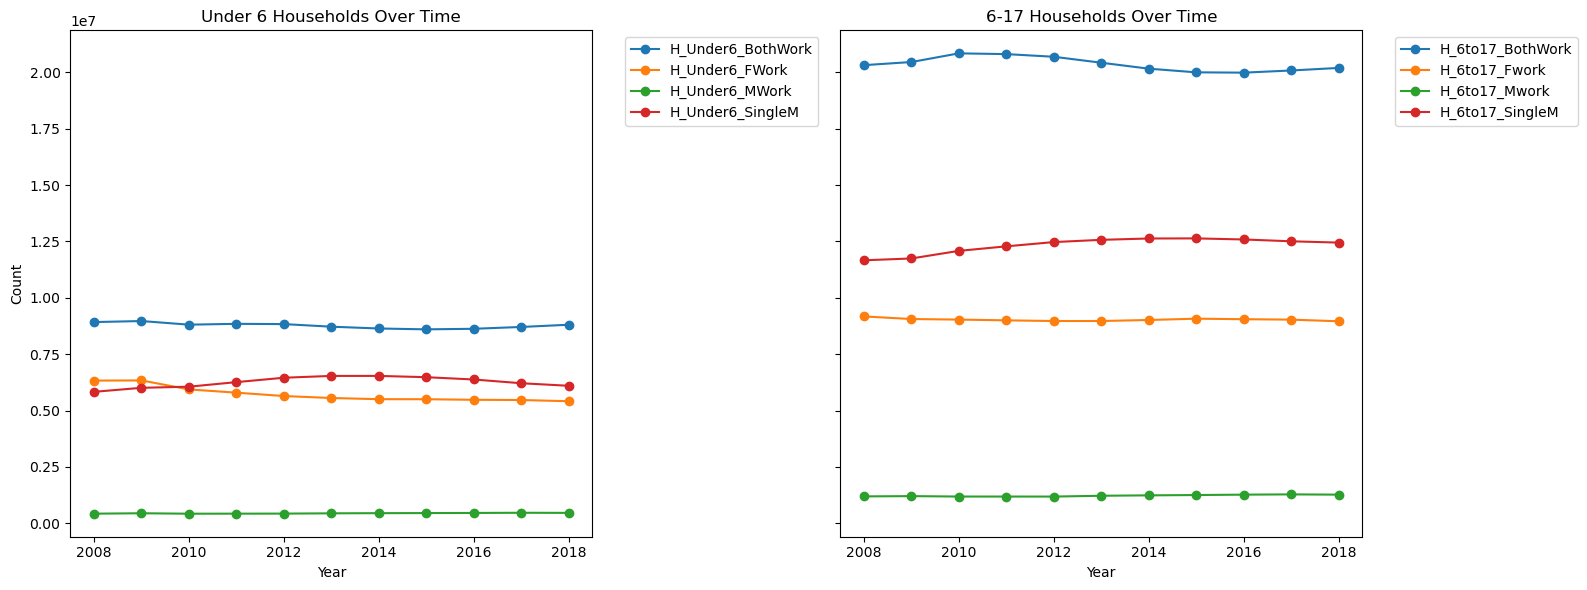

In [14]:
# Groups households with children under 6 (excludes imputation columns)
under_6 = [col for col in cols if 'H_Under6' in col and not col.startswith('i')]
under_6_counts = childcare_df.groupby('StudyYear')[under_6].sum()

# Groups households with children 6-17 (excludes imputation columns)
age_6_17 = [col for col in cols if 'H_6to17' in col and not col.startswith('i')]
age_6_17_counts = childcare_df.groupby('StudyYear')[age_6_17].sum()

# Creates subplots for side-by-side for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plots under 6 group
for col in under_6: 
    ax1.plot(under_6_counts.index, under_6_counts[col], marker='o', label=col)
ax1.set_title('Under 6 Households Over Time')
ax1.set_xlabel('Year')
ax1.set_ylabel('Count')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plots 6-17 group
for col in age_6_17: 
    ax2.plot(age_6_17_counts.index, age_6_17_counts[col], marker='o', label=col)
ax2.set_title('6-17 Households Over Time')
ax2.set_xlabel('Year')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

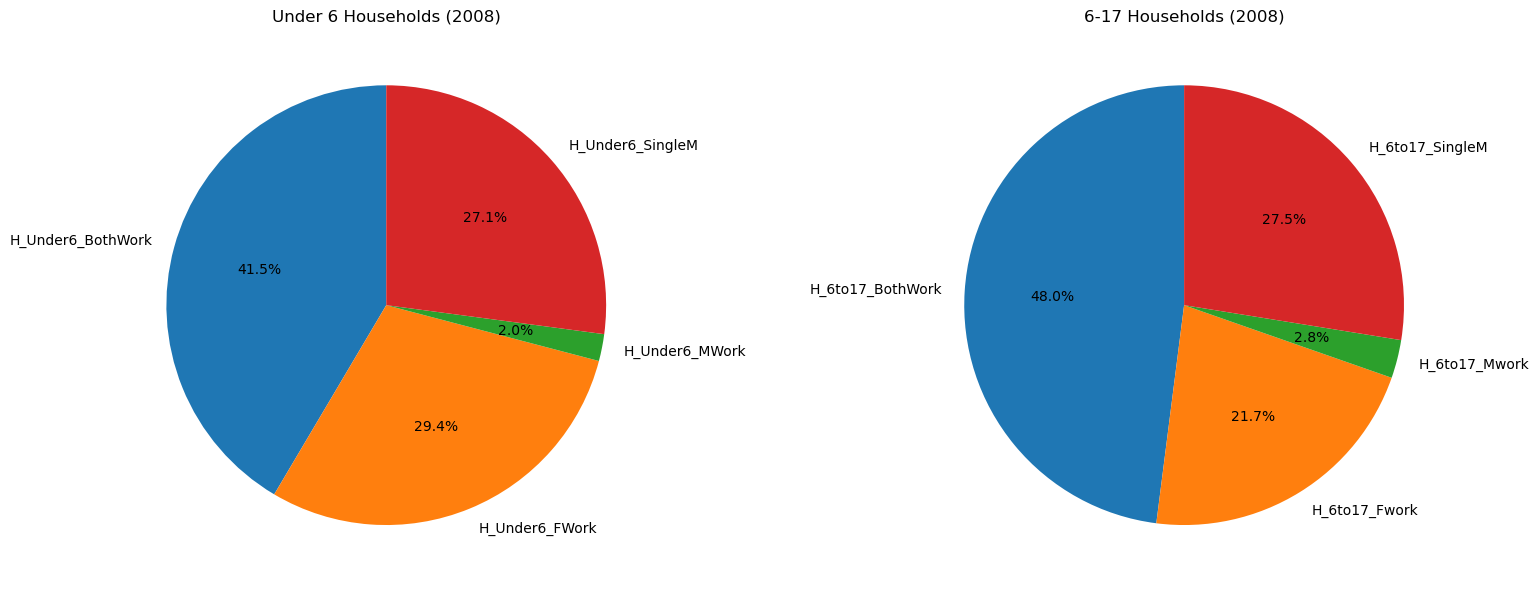

In [91]:
# Locates year of interest using previously established variable
first_year = under_6_counts.index.min()
under_6_pie = under_6_counts.loc[first_year]
age_6_17_pie = age_6_17_counts.loc[first_year]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plots under 6 pie chart for 2008
ax1.pie(under_6_pie, labels=under_6_pie.index, autopct='%1.1f%%', startangle=90)
ax1.set_title(f'Under 6 Households ({first_year})')

# Plots 6-17 pie chart for 2008
ax2.pie(age_6_17_pie, labels=age_6_17_pie.index, autopct='%1.1f%%', startangle=90)
ax2.set_title(f'6-17 Households ({first_year})')

plt.tight_layout()
plt.show()

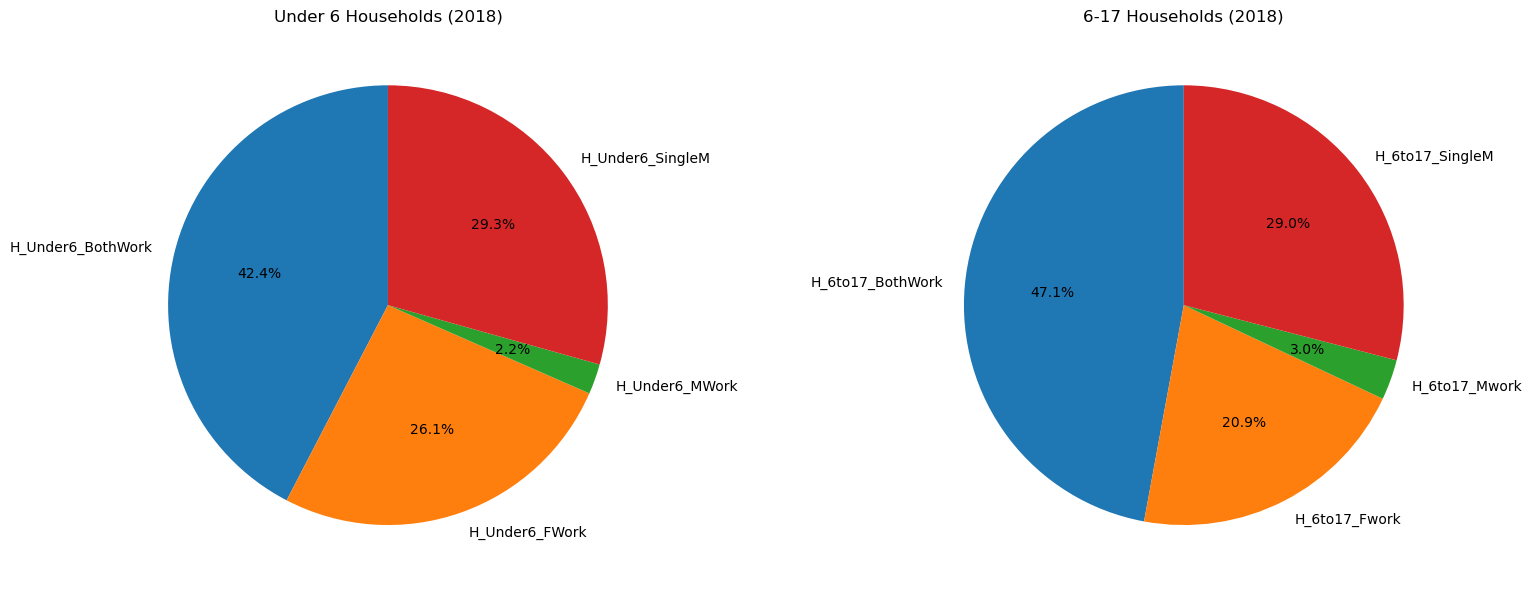

In [92]:
# Use most recent year for pie charts (or specify e.g., 2018)
latest_year = under_6_counts.index.max()
under_6_pie = under_6_counts.loc[latest_year]
age_6_17_pie = age_6_17_counts.loc[latest_year]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plots under 6 pie chart for 2018
ax1.pie(under_6_pie, labels=under_6_pie.index, autopct='%1.1f%%', startangle=90)
ax1.set_title(f'Under 6 Households ({latest_year})')

# Plots 6-17 pie chart for 2018
ax2.pie(age_6_17_pie, labels=age_6_17_pie.index, autopct='%1.1f%%', startangle=90)
ax2.set_title(f'6-17 Households ({latest_year})')

plt.tight_layout()
plt.show()

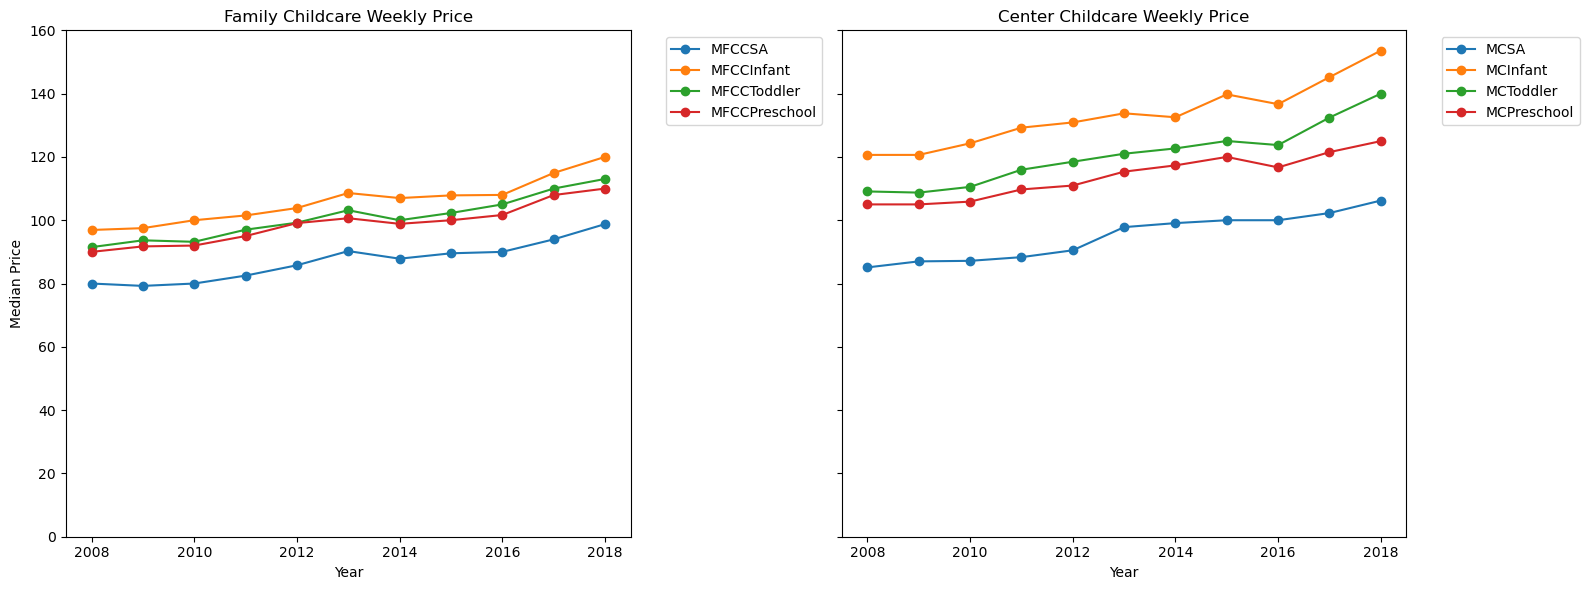

In [170]:
# Groups median family price columns for plotting
agg_family_cols = [col for col in cols if 
                  any(pattern in col for pattern in ['MFCCSA', 'MFCCInfant', 
                                                     'MFCCToddler', 
                                                     'MFCCPreschool']) and not 
                  col.startswith('i') and not col.endswith('flag')]
# Calculates median of family chilcare county aggregated medians 
agg_family_medians = childcare_df.groupby('StudyYear')[agg_family_cols].median()

# Groups median center price columns for plotting
agg_center_cols = [col for col in cols if 
                  any(pattern in col for pattern in ['MCSA', 'MCInfant', 
                                                     'MCToddler', 
                                                     'MCPreschool']) and not 
                  col.startswith('i') and not col.endswith('flag')]

# Calculates median of center childcare county aggregated medians 
agg_center_medians = childcare_df.groupby('StudyYear')[agg_center_cols].median()

# Creates subplots for side-by-side for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plots under 6 group
for col in agg_family_cols: 
    ax1.plot(agg_family_medians.index, agg_family_medians[col], marker='o', 
             label=col)
ax1.set_title('Family Childcare Weekly Price')
ax1.set_xlabel('Year')
ax1.set_ylabel('Median Price')
ax1.set_ylim(0, 160)  
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plots 6-17 group
for col in agg_center_cols: 
    ax2.plot(agg_center_medians.index, agg_center_medians[col], marker='o', 
             label=col)
ax2.set_title('Center Childcare Weekly Price')
ax2.set_xlabel('Year')
ax2.set_ylim(0, 160)  
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Percentage of Median Income Over Time 

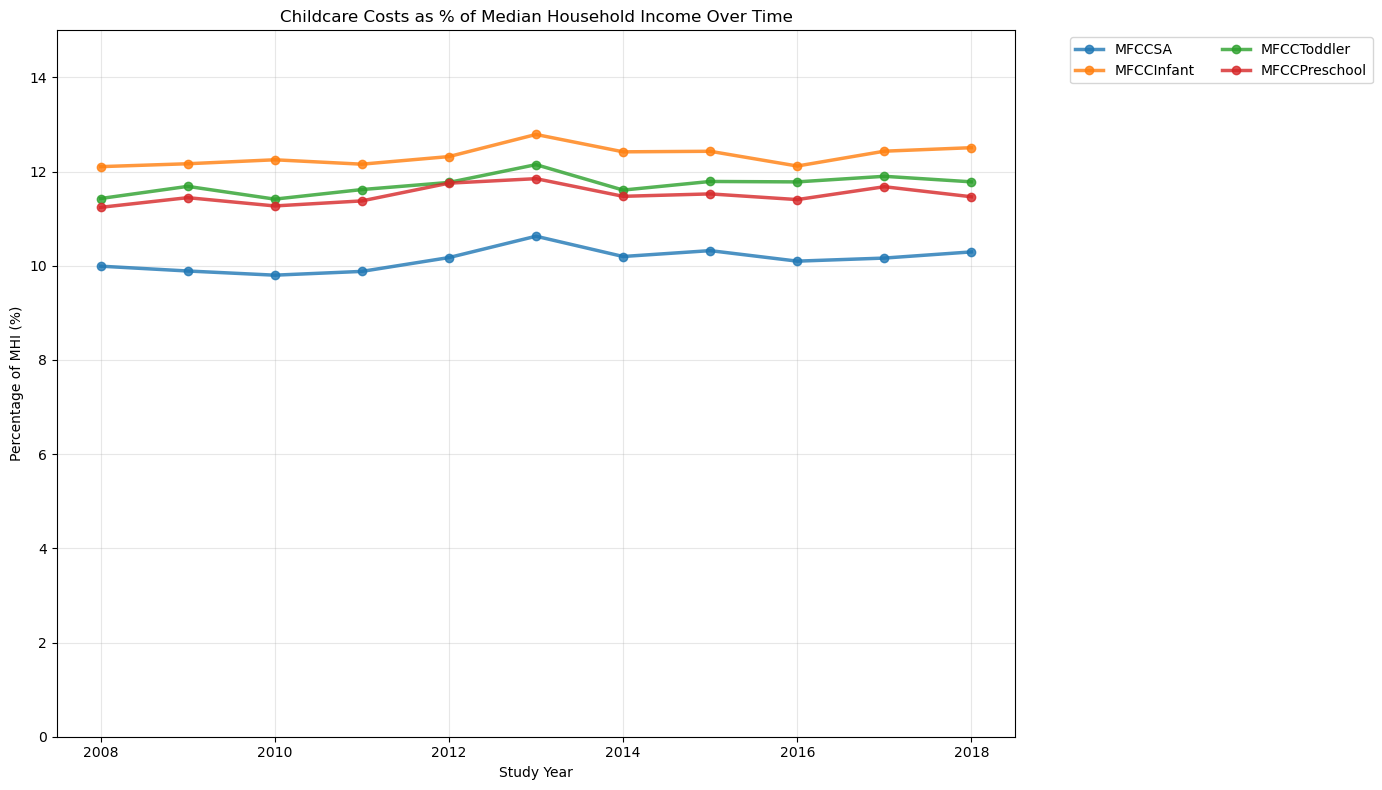

In [9]:
# Groups columns by year, multplies median by 52 to calculate median yearly cost
agg_family_yearly = childcare_df.groupby('StudyYear')[agg_family_cols].median() * 52
mhi_yearly = childcare_df.groupby('StudyYear')['MHI'].median()

# Calculates proportion of childcare costs to median household income
agg_family_proportions = agg_family_yearly.div(mhi_yearly, axis=0) * 100  

fig, ax = plt.subplots(figsize=(12, 8))

# Plots each childcare category as % of MHI over time
for col in agg_family_cols:
    ax.plot(agg_family_proportions.index, agg_family_proportions[col], 
            marker='o', linewidth=2.5, label=col, alpha=0.8)

ax.set_title('Childcare Costs as % of Median Household Income Over Time')
ax.set_xlabel('Study Year')
ax.set_ylabel('Percentage of MHI (%)')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 15)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

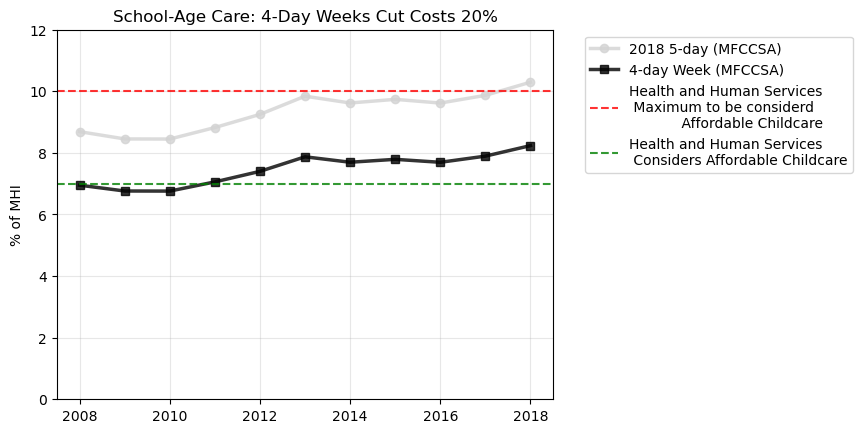

In [172]:
current_burden = agg_family_yearly.div(mhi_yearly, axis=0) * 100 

# Calculates 4-day week burden (80% of 5-day costs)
four_day_burden = current_burden * 0.8

# Plots 2018 vs 4-day burden over time (using first column as example)
first_col = agg_family_cols[0] 
plt.plot(current_burden.index, current_burden[first_col], 'lightgray', 
         linewidth=2.5, 
         marker='o', label=f'2018 5-day ({first_col})', alpha=0.8)
plt.plot(four_day_burden.index, four_day_burden[first_col], 'k-', linewidth=2.5, 
         marker='s', label=f'4-day Week ({first_col})', alpha=0.8)
plt.axhline(y=10, color='red', linestyle='--', alpha=0.8, 
            label='Health and Human Services\n Maximum to be considerd\n\
            Affordable Childcare')
plt.axhline(y=7, color='green', linestyle='--', alpha=0.8, 
            label='Health and Human Services\n Considers Affordable Childcare')
plt.title(f'School-Age Care: 4-Day Weeks Cut Costs 20%')
plt.ylabel('% of MHI')
plt.ylim(0, 12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()